# Car Segmentation Using U-Net
-Yashita Bahrani

This project builds a car segmentation system using deep learning.

The pipeline includes:

1. Dataset collection
2. Automatic mask generation using YOLOv8 segmentation
3. Training a baseline U-Net model
4. Improving the model using a pretrained ResNet encoder and data augmentation
5. Evaluating models using IoU, Dice score, and Pixel Accuracy

In [ ]:
import pandas as pd
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
!pip install ultralytics
from ultralytics import YOLO
from torchvision import transforms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Dataset

We use the Kaggle car detection dataset containing road images with cars.

Images are extracted from the dataset and segmentation masks are automatically generated using the YOLOv8 segmentation model.

Dataset source:
https://www.kaggle.com/datasets/sshikamaru/car-object-detection

In [ ]:
!unzip "archive (2).zip"

Archive:  archive (2).zip
  inflating: data/sample_submission.csv  
  inflating: data/testing_images/vid_5_25100.jpg  
  inflating: data/testing_images/vid_5_25120.jpg  
  inflating: data/testing_images/vid_5_25140.jpg  
  inflating: data/testing_images/vid_5_25160.jpg  
  inflating: data/testing_images/vid_5_25180.jpg  
  inflating: data/testing_images/vid_5_25200.jpg  
  inflating: data/testing_images/vid_5_25220.jpg  
  inflating: data/testing_images/vid_5_25240.jpg  
  inflating: data/testing_images/vid_5_25260.jpg  
  inflating: data/testing_images/vid_5_26320.jpg  
  inflating: data/testing_images/vid_5_26400.jpg  
  inflating: data/testing_images/vid_5_26420.jpg  
  inflating: data/testing_images/vid_5_26560.jpg  
  inflating: data/testing_images/vid_5_26580.jpg  
  inflating: data/testing_images/vid_5_26600.jpg  
  inflating: data/testing_images/vid_5_26620.jpg  
  inflating: data/testing_images/vid_5_26640.jpg  
  inflating: data/testing_images/vid_5_26660.jpg  
  inflating: d

In [ ]:
!ls -lh

total 113M
-rw-r--r-- 1 root root 113M Mar 15 17:16 'archive (2).zip'
drwxr-xr-x 4 root root 4.0K Mar 15 17:16  data
drwxr-xr-x 1 root root 4.0K Feb  6 14:31  sample_data


In [ ]:
!ls data

 sample_submission.csv	 training_images
 testing_images		'train_solution_bounding_boxes (1).csv'


In [ ]:
!ls data/training_images | head

vid_4_10000.jpg
vid_4_1000.jpg
vid_4_10020.jpg
vid_4_10040.jpg
vid_4_10060.jpg
vid_4_10080.jpg
vid_4_10100.jpg
vid_4_10120.jpg
vid_4_10140.jpg
vid_4_10160.jpg


In [ ]:
image_dir = "/content/data/training_images"
mask_dir = "/content/masks"

os.makedirs(mask_dir, exist_ok=True)

In [ ]:
df = pd.read_csv("/content/data/train_solution_bounding_boxes (1).csv")
df.head()

,image,xmin,ymin,xmax,ymax
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422


## Automatic Mask Generation

The dataset originally contains bounding boxes but not segmentation masks.

To create pixel-level annotations, we use YOLOv8 segmentation (yolov8n-seg).

For each image:
1. YOLO detects car objects
2. Polygon masks are extracted
3. Binary segmentation masks are generated
4. Masks are saved for training

In [ ]:
model = YOLO("yolov8n-seg.pt")

image_list = os.listdir(image_dir)

for img_name in image_list:

    img_path = os.path.join(image_dir, img_name)

    results = model(img_path, verbose=False)

    img = cv2.imread(img_path)

    mask = np.zeros(img.shape[:2], dtype=np.uint8)

    for r in results:
        if r.masks is not None:
            for seg in r.masks.xy:  # r.masks.xy gives:polygon coordinates of each detected car
                pts = np.array(seg, dtype=np.int32)
                cv2.fillPoly(mask, [pts], 255)

    mask_path = os.path.join(mask_dir, img_name.replace(".jpg",".png"))

    cv2.imwrite(mask_path, mask)


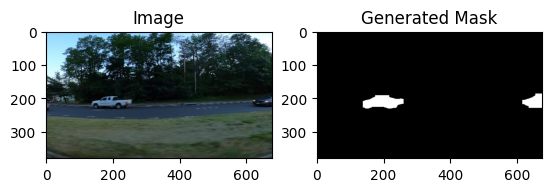

In [ ]:
img_name = os.listdir(mask_dir)[0]

img = cv2.imread(os.path.join(image_dir, img_name.replace(".png",".jpg")))
mask = cv2.imread(os.path.join(mask_dir, img_name),0)

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask,cmap="gray")
plt.title("Generated Mask")

plt.show()


## Generated Segmentation Masks

Below are examples of the automatically generated segmentation masks.

White pixels represent detected car regions.
Black pixels represent background.

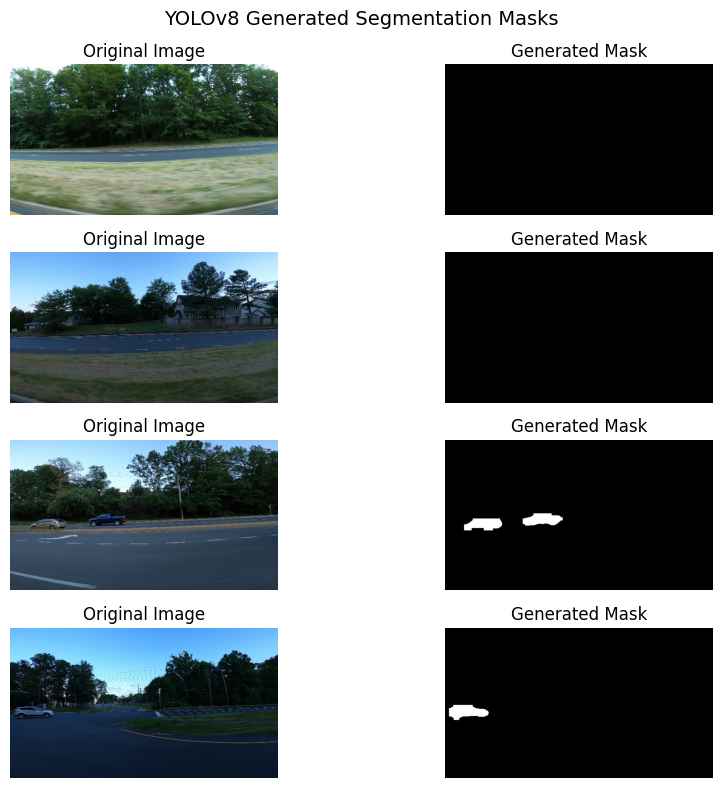

In [ ]:
import random

mask_files = os.listdir(mask_dir)
sample_masks = random.sample(mask_files, 4)

plt.figure(figsize=(10,8))

for i, m in enumerate(sample_masks):

    img_path = os.path.join(image_dir, m.replace(".png",".jpg"))
    mask_path = os.path.join(mask_dir, m)

    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path,0)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(4,2,2*i+1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(4,2,2*i+2)
    plt.imshow(mask, cmap="gray")
    plt.title("Generated Mask")
    plt.axis("off")

plt.suptitle("YOLOv8 Generated Segmentation Masks", fontsize=14)
plt.tight_layout()
plt.show()

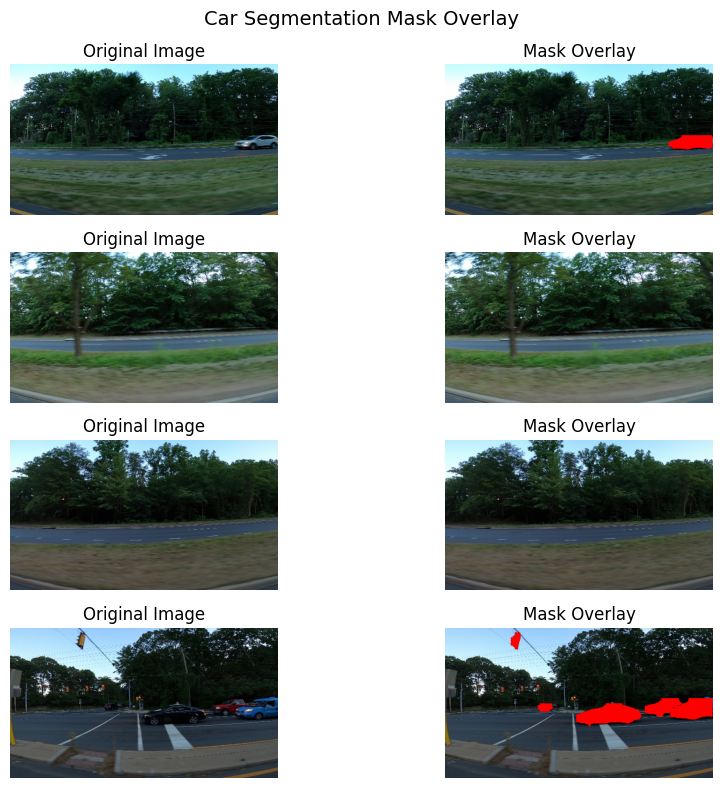

In [ ]:
import random

mask_files = os.listdir(mask_dir)
sample_masks = random.sample(mask_files, 4)

plt.figure(figsize=(10,8))

for i, m in enumerate(sample_masks):

    img = cv2.imread(os.path.join(image_dir, m.replace(".png",".jpg")))
    mask = cv2.imread(os.path.join(mask_dir, m),0)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    overlay = img.copy()
    overlay[mask > 0] = [255,0,0]   # red highlight

    plt.subplot(4,2,2*i+1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(4,2,2*i+2)
    plt.imshow(overlay)
    plt.title("Mask Overlay")
    plt.axis("off")

plt.suptitle("Car Segmentation Mask Overlay", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
class CarDataset(Dataset):

    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir

        self.images = []

        for f in os.listdir(img_dir):

            mask_path = os.path.join(mask_dir, f.replace(".jpg",".png"))

            if os.path.exists(mask_path):

                mask = cv2.imread(mask_path, 0)

                if mask is not None and mask.sum() > 0:   # skip empty masks
                    self.images.append(f)


        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((256,256)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name.replace(".jpg",".png"))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)

        img = self.transform(img)

        mask = cv2.resize(mask,(256,256))
        mask = torch.tensor(mask/255.0).unsqueeze(0).float()

        return img, mask


In [ ]:
dataset = CarDataset(image_dir, mask_dir)

loader = DataLoader(dataset, batch_size=4, shuffle=True)

print("Dataset size:", len(dataset))

Dataset size: 505


## Model 1: Vanilla U-Net

A basic U-Net architecture is implemented for semantic segmentation.

Architecture:
Encoder → Bottleneck → Decoder

Loss function: Binary Cross Entropy  
Optimizer: Adam  
Learning Rate: 1e-4  
Epochs: 25

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

def conv_block(i,o):
    return nn.Sequential(
        nn.Conv2d(i,o,3,1,1),
        nn.ReLU(),
        nn.Conv2d(o,o,3,1,1),
        nn.ReLU()
    )

class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.e1 = conv_block(3,64)
        self.e2 = conv_block(64,128)

        self.pool = nn.MaxPool2d(2)   #downsampling (encoder part of unet) : feature extraction
        self.up = nn.Upsample(scale_factor=2)  #upsampling (decoder part of unet) : restores spatial resolution of features

        self.bottleneck = conv_block(128,256) #bottleneck: captures the most abstract features

        self.d2 = conv_block(256+128,128)
        self.d1 = conv_block(128+64,64)

        self.final = nn.Conv2d(64,1,1)  #Output layer:  1 channel for binary segmentation

    def forward(self,x):
        c1 = self.e1(x)
        c2 = self.e2(self.pool(c1))

        b = self.bottleneck(self.pool(c2))

        d2 = self.d2(torch.cat([self.up(b),c2],1))
        d1 = self.d1(torch.cat([self.up(d2),c1],1))

        return torch.sigmoid(self.final(d1))   #Sigmoid activation :correct for binary mask output

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

criterion = nn.BCELoss()

In [ ]:
loss_history = []

epochs = 25

model.train()

for e in range(epochs):

    total_loss = 0

    for imgs, masks in loader:

        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = model(imgs)

        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    print(f"Epoch {e+1}/{epochs} | Loss: {avg_loss:.4f}")


Epoch 1/25 | Loss: 0.1746
Epoch 2/25 | Loss: 0.0620
Epoch 3/25 | Loss: 0.0442
Epoch 4/25 | Loss: 0.0356
Epoch 5/25 | Loss: 0.0277
Epoch 6/25 | Loss: 0.0252
Epoch 7/25 | Loss: 0.0198
Epoch 8/25 | Loss: 0.0225
Epoch 9/25 | Loss: 0.0175
Epoch 10/25 | Loss: 0.0163
Epoch 11/25 | Loss: 0.0253
Epoch 12/25 | Loss: 0.0166
Epoch 13/25 | Loss: 0.0151
Epoch 14/25 | Loss: 0.0142
Epoch 15/25 | Loss: 0.0154
Epoch 16/25 | Loss: 0.0137
Epoch 17/25 | Loss: 0.0135
Epoch 18/25 | Loss: 0.0126
Epoch 19/25 | Loss: 0.0141
Epoch 20/25 | Loss: 0.0119
Epoch 21/25 | Loss: 0.0116
Epoch 22/25 | Loss: 0.0122
Epoch 23/25 | Loss: 0.0115
Epoch 24/25 | Loss: 0.0107
Epoch 25/25 | Loss: 0.0115


In [ ]:
model.eval()

with torch.no_grad():

    imgs, masks = next(iter(loader))

    imgs = imgs.to(device)
    masks = masks.to(device)

    preds = model(imgs)
    preds = (preds > 0.5).float()

    intersection = (preds * masks).sum()
    union = ((preds + masks) > 0).sum()

    iou = intersection / (union + 1e-6)

    dice = (2 * intersection) / (preds.sum() + masks.sum() + 1e-6)

    pixel_acc = (preds == masks).float().mean()

    print("IoU:", iou.item())
    print("Dice:", dice.item())
    print("Pixel Accuracy:", pixel_acc.item())


IoU: 0.5860111117362976
Dice: 0.754152774810791
Pixel Accuracy: 0.9871559143066406


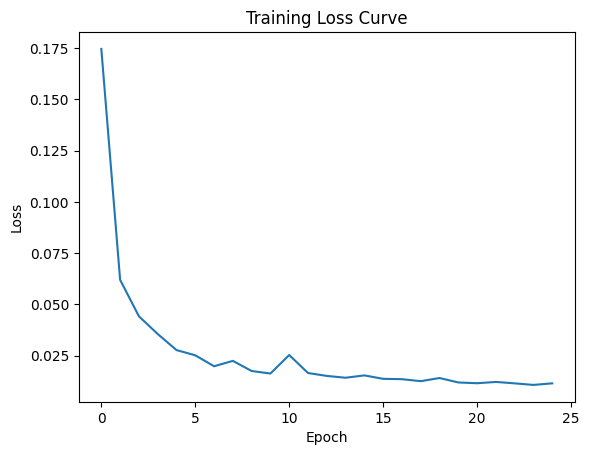

In [ ]:
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


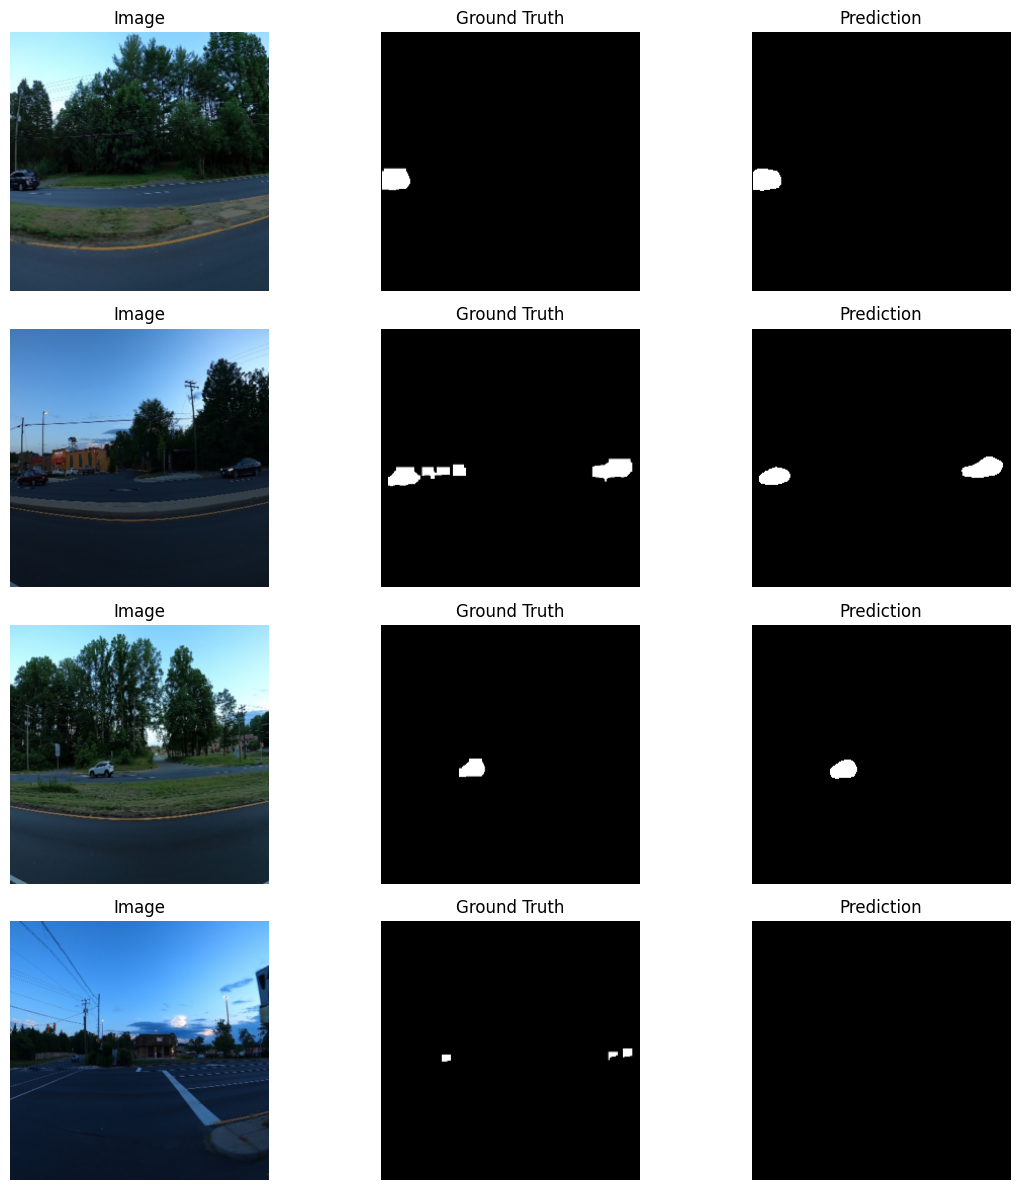

In [ ]:
model.eval()

imgs, masks = next(iter(loader))

imgs = imgs.to(device)
masks = masks.to(device)

with torch.no_grad():
    preds = model(imgs)
    preds = (preds > 0.5).float()

num_samples = imgs.shape[0]   # automatically use batch size

plt.figure(figsize=(12, num_samples * 3))

for i in range(num_samples):

    plt.subplot(num_samples, 3, i*3 + 1)
    plt.imshow(imgs[i].cpu().permute(1,2,0))
    plt.title("Image")
    plt.axis("off")

    plt.subplot(num_samples, 3, i*3 + 2)
    plt.imshow(masks[i][0].cpu(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(num_samples, 3, i*3 + 3)
    plt.imshow(preds[i][0].cpu(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
torch.save(model.state_dict(), "unet_car_segmentation.pth")

## Model 2: ResNet Encoder U-Net + Data Augmentation

To improve segmentation performance:

1. A pretrained ResNet34 encoder is used (transfer learning)
2. Data augmentation is applied during training:
   - Horizontal flip
   - Random rotation
3. Dice Loss is combined with BCE loss for better segmentation accuracy

In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.9 MB/s eta 0:00:00


In [ ]:
import segmentation_models_pytorch as smp

In [ ]:
model2 = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
bce = torch.nn.BCEWithLogitsLoss()

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-6
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def loss_fn(pred, target):
    return bce(pred, target) + dice_loss(pred, target)

In [ ]:
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-4)

In [ ]:
import torchvision.transforms.functional as TF
import random
def augment_batch(imgs, masks):

    for i in range(imgs.size(0)):

        # horizontal flip
        if random.random() > 0.5:
            imgs[i] = TF.hflip(imgs[i])
            masks[i] = TF.hflip(masks[i])

        # random rotation
        angle = random.uniform(-10,10)
        imgs[i] = TF.rotate(imgs[i], angle)
        masks[i] = TF.rotate(masks[i], angle)

    return imgs, masks

Model-2 Training (ResNet-U-Net + Augmentation + Loss Curve)

In [ ]:
loss_history2 = []

epochs2 = 15

model2.train()

for e in range(epochs2):

    total_loss = 0

    for imgs, masks in loader:

        # augmentation
        imgs, masks = augment_batch(imgs, masks)

        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = model2(imgs)

        loss = loss_fn(preds, masks)

        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    loss_history2.append(avg_loss)

    print(f"Epoch {e+1}/{epochs2} | Loss: {avg_loss:.4f}")

Epoch 1/15 | Loss: 0.1255
Epoch 2/15 | Loss: 0.1274
Epoch 3/15 | Loss: 0.1368
Epoch 4/15 | Loss: 0.1240
Epoch 5/15 | Loss: 0.1513
Epoch 6/15 | Loss: 0.1243
Epoch 7/15 | Loss: 0.1244
Epoch 8/15 | Loss: 0.1224
Epoch 9/15 | Loss: 0.1160
Epoch 10/15 | Loss: 0.1237
Epoch 11/15 | Loss: 0.1224
Epoch 12/15 | Loss: 0.1206
Epoch 13/15 | Loss: 0.1197
Epoch 14/15 | Loss: 0.1138
Epoch 15/15 | Loss: 0.1127


Model	Improvements

Model 1	Vanilla U-Net

Model 2	ResNet encoder + augmentation

The second model incorporates transfer learning using a pretrained ResNet34 encoder along with data augmentation techniques such as horizontal flipping and rotation to improve generalization.

Old model loss:
BCELoss

New model loss:
BCEWithLogitsLoss + Dice Loss

So the new loss is:

Total Loss = BCE + Dice

Evaluate Model-2 (IoU, Dice, Pixel Accuracy)


In [ ]:
model2.eval()

with torch.no_grad():

    imgs, masks = next(iter(loader))

    imgs = imgs.to(device)
    masks = masks.to(device)

    preds = model2(imgs)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    intersection = (preds * masks).sum()
    union = ((preds + masks) > 0).sum()

    iou = intersection / (union + 1e-6)

    dice = (2 * intersection) / (preds.sum() + masks.sum() + 1e-6)

    pixel_acc = (preds == masks).float().mean()

    print("IoU:", iou.item())
    print("Dice:", dice.item())
    print("Pixel Accuracy:", pixel_acc.item())

IoU: 0.8032897114753723
Dice: 0.9033952951431274
Pixel Accuracy: 0.998382568359375


## Evaluation Metrics

The models are evaluated using:

IoU (Intersection over Union)  
Dice Coefficient  
Pixel Accuracy

Plot Training Loss for Model-2

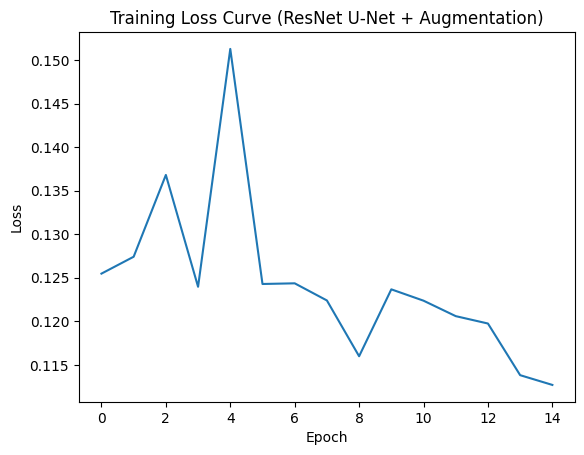

In [ ]:
plt.plot(loss_history2)
plt.title("Training Loss Curve (ResNet U-Net + Augmentation)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

The spikes happen because:

data augmentation changes images each epoch

batch sampling randomness

Adam optimizer noise

That spike (~0.151) likely came from a hard augmented batch, e.g.:

rotated car partly outside frame

flipped image confusing early layers

brightness shift affecting features

This is exactly what augmentation is meant to do: make training harder so the model generalizes better.

Visualization (Image | Ground Truth | Prediction)

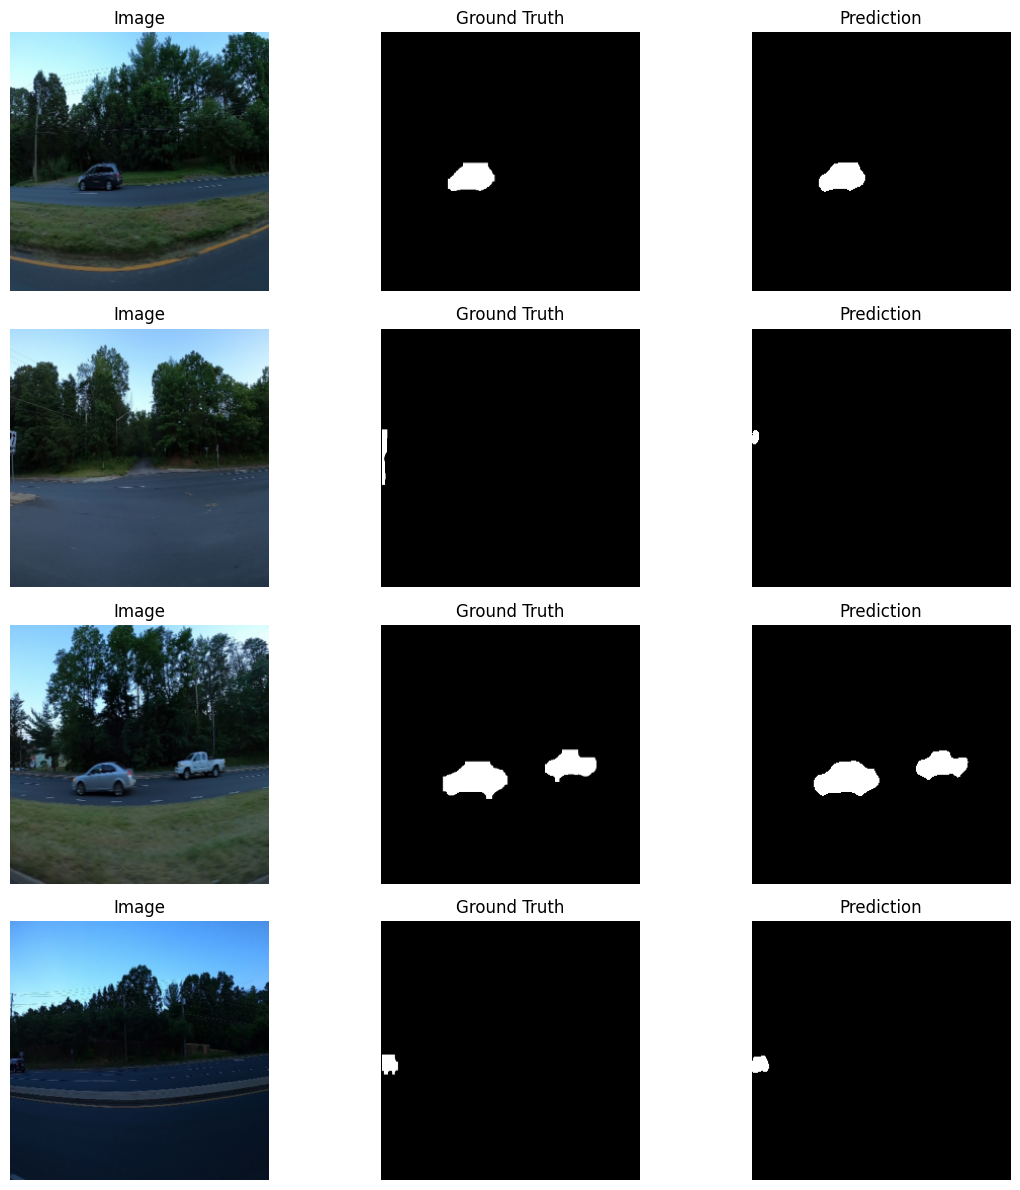

In [ ]:
model2.eval()

imgs, masks = next(iter(loader))

imgs = imgs.to(device)
masks = masks.to(device)

with torch.no_grad():
    preds = model2(imgs)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

num_samples = imgs.shape[0]

plt.figure(figsize=(12, num_samples * 3))

for i in range(num_samples):

    plt.subplot(num_samples, 3, i*3 + 1)
    plt.imshow(imgs[i].cpu().permute(1,2,0))
    plt.title("Image")
    plt.axis("off")

    plt.subplot(num_samples, 3, i*3 + 2)
    plt.imshow(masks[i][0].cpu(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(num_samples, 3, i*3 + 3)
    plt.imshow(preds[i][0].cpu(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
torch.save(model2.state_dict(), "resnet_unet_car_segmentation.pth")

The improved model using a pretrained ResNet34 encoder and data augmentation significantly outperformed the baseline U-Net. The IoU improved from 0.586 to 0.803, while the Dice score increased from 0.754 to 0.903, indicating better segmentation overlap with ground truth masks. Pixel accuracy also improved, demonstrating the effectiveness of transfer learning and augmentation techniques in improving segmentation performance.

### Model Performance Comparison

| Model | IoU | Dice | Pixel Accuracy |
|------|------|------|------|
| Vanilla U-Net | 0.586 | 0.754 | 0.987 |
| ResNet U-Net + Augmentation | 0.803 | 0.903 | 0.998 |

## Conclusion

A custom car segmentation dataset was created using YOLOv8 segmentation.

Two models were trained:

1. Vanilla U-Net
2. ResNet34 U-Net with augmentation

The improved model achieved significantly higher IoU and Dice scores, demonstrating the effectiveness of transfer learning and data augmentation for semantic segmentation tasks.